IMPORT LIBRARIES

In [32]:
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd 
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

Load Data & Inspect

In [33]:
data = pd.read_csv('final_data.csv')

print("--- First 10 Rows ---")
print(data.head(10))

print("\n--- DataFrame Info ---")
data.info()

df = data.copy()

--- First 10 Rows ---
   user_id          signup_time        purchase_time  purchase_value  \
0   247547  2015-06-28 03:00:34  2015-08-09 03:57:29              47   
1   220737  2015-01-28 14:21:11  2015-02-11 20:28:28              15   
2   390400  2015-03-19 20:49:09  2015-04-11 23:41:23              44   
3    69592  2015-02-24 06:11:57  2015-05-23 16:40:14              55   
4   174987  2015-07-07 12:58:11  2015-11-03 04:04:30              51   
5    23204  2015-06-15 21:47:39  2015-08-02 04:35:34              25   
6   155230  2015-03-15 08:27:21  2015-05-21 13:55:15              37   
7   199369  2015-01-17 14:38:23  2015-03-15 18:13:39              43   
8   236894  2015-06-16 04:02:41  2015-07-25 01:29:33              22   
9   379446  2015-04-11 13:13:27  2015-07-03 22:27:10              49   

       device_id  source browser sex  age    ip_address  class  \
0  KIXYSVCHIPQBR     SEO  Safari   F   30  1.677886e+07      0   
1  PKYOWQKWGJNJI     SEO  Chrome   F   34  1.684205e+

FEATURE ENGINEERING

Device ID Feature Engineering

In [ ]:
device_counts = df.groupby('device_id')['user_id'].nunique()
df['device_id_user_counts'] = df['device_id'].map(device_counts)

import joblib
joblib.dump(device_counts, 'encoders/device_counts_map.joblib')

max_users = df['device_id_user_counts'].max()
print(f"The maximum number of unique users on a single device is: {max_users}")

df_sorted_by_device = df.sort_values('device_id_user_counts', ascending=False)

print("Top 10 devices by number of unique users:")
print(df_sorted_by_device.head(10))

print("\nDistribution of user counts per device:")
print(df['device_id_user_counts'].value_counts())

df.head()

The maximum number of unique users on a single device is: 20
Top 10 devices by number of unique users:
       user_id          signup_time        purchase_time  purchase_value  \
11331    65147  2015-01-04 15:02:04  2015-01-04 15:02:05              32   
51650   101698  2015-01-06 06:33:21  2015-01-06 06:33:22              47   
51641   257171  2015-01-06 06:33:18  2015-03-29 03:32:06              47   
51642    52655  2015-01-06 06:33:31  2015-01-06 06:33:32              47   
51643   216960  2015-01-06 06:33:33  2015-01-06 06:33:34              47   
51644     8863  2015-01-06 06:33:26  2015-01-06 06:33:27              47   
51645   308527  2015-01-06 06:33:29  2015-01-06 06:33:30              47   
51646   315519  2015-01-06 06:33:20  2015-01-06 06:33:21              47   
19529    74754  2015-01-03 10:47:48  2015-01-03 10:47:49              58   
51647   151070  2015-01-06 06:33:27  2015-01-06 06:33:28              47   

           device_id source browser sex  age    ip_address  

,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class,lower_bound_ip_address,upper_bound_ip_address,country,device_id_user_counts
0,247547,2015-06-28 03:00:34,2015-08-09 03:57:29,47,KIXYSVCHIPQBR,SEO,Safari,F,30,1.677886e+07,0,16778240.0,16779263.0,Australia,1
1,220737,2015-01-28 14:21:11,2015-02-11 20:28:28,15,PKYOWQKWGJNJI,SEO,Chrome,F,34,1.684205e+07,0,16809984.0,16842751.0,Thailand,1
2,390400,2015-03-19 20:49:09,2015-04-11 23:41:23,44,LVCSXLISZHVUO,Ads,IE,M,29,1.684366e+07,0,16843264.0,16843775.0,China,2
3,69592,2015-02-24 06:11:57,2015-05-23 16:40:14,55,UHAUHNXXUADJE,Direct,Chrome,F,30,1.693873e+07,0,16924672.0,16941055.0,China,1
4,174987,2015-07-07 12:58:11,2015-11-03 04:04:30,51,XPGPMOHIDRMGE,SEO,Chrome,F,37,1.697198e+07,0,16941056.0,16973823.0,Thailand,1


IP Address Column Cleanup

In [35]:
df.drop(['ip_address'],axis=1, inplace=True)
df.drop(['lower_bound_ip_address'],axis=1, inplace=True)
df.drop(['upper_bound_ip_address'],axis=1, inplace=True)

df.head()

fraud = df[df['class'] == 1]
valid = df[df['class'] == 0]
print('Total Cases: {}'.format(len(df['class'])))
print('Fraud Cases: {}'.format(len(df[df['class'] == 1])))
print('Valid Transactions: {}'.format(len(df[df['class'] == 0])))

Total Cases: 129146
Fraud Cases: 12268
Valid Transactions: 116878


Time Difference Feature Engineering

In [36]:
# EXTRACTING THE TIME DIFFERENCE BETWEEN SIGNUP AND PURCHASE TIME
df["signup_time"] = pd.to_datetime(df["signup_time"], format="%Y-%m-%d %H:%M:%S")
df["purchase_time"] = pd.to_datetime(df["purchase_time"], format="%Y-%m-%d %H:%M:%S")

df["time_diff_min"] = (df["purchase_time"] - df["signup_time"]).dt.total_seconds() / 60

df.head(20)

,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,class,country,device_id_user_counts,time_diff_min
0,247547,2015-06-28 03:00:34,2015-08-09 03:57:29,47,KIXYSVCHIPQBR,SEO,Safari,F,30,0,Australia,1,60536.916667
1,220737,2015-01-28 14:21:11,2015-02-11 20:28:28,15,PKYOWQKWGJNJI,SEO,Chrome,F,34,0,Thailand,1,20527.283333
2,390400,2015-03-19 20:49:09,2015-04-11 23:41:23,44,LVCSXLISZHVUO,Ads,IE,M,29,0,China,2,33292.233333
3,69592,2015-02-24 06:11:57,2015-05-23 16:40:14,55,UHAUHNXXUADJE,Direct,Chrome,F,30,0,China,1,127348.283333
4,174987,2015-07-07 12:58:11,2015-11-03 04:04:30,51,XPGPMOHIDRMGE,SEO,Chrome,F,37,0,Thailand,1,170826.316667
5,23204,2015-06-15 21:47:39,2015-08-02 04:35:34,25,CSFNDSDBQATBA,Ads,IE,F,43,0,China,1,68087.916667
6,155230,2015-03-15 08:27:21,2015-05-21 13:55:15,37,BRDZLYDRFATRF,Ads,Chrome,F,46,0,Thailand,1,96807.900000
7,199369,2015-01-17 14:38:23,2015-03-15 18:13:39,43,MURSXNWVBRZVM,Direct,IE,M,37,0,Japan,2,82295.266667
8,236894,2015-06-16 04:02:41,2015-07-25 01:29:33,22,YXWLWLZBQVBMG,Ads,Chrome,M,31,0,Japan,1,56006.866667
9,379446,2015-04-11 13:13:27,2015-07-03 22:27:10,49,FAWCZLEWWUDVD,SEO,Chrome,M,24,0,Japan,2,120073.716667


Dropping Unused IDs

In [37]:
df.drop(['device_id'],axis=1, inplace=True)
df.drop(['user_id'],axis=1, inplace=True)

Datetime Feature Engineering

In [38]:
# EXTRACTING HOURLY, DAY OF THE WEEK, AND DAY IN A MONTH FEATURES
df["signup_hour"] = df["signup_time"].dt.hour
df["purchase_hour"] = df["purchase_time"].dt.hour
df["purchase_dayofweek"] = df["purchase_time"].dt.dayofweek
df["purchase_month"] = df["purchase_time"].dt.month 

print(pd.crosstab(df['purchase_hour'], df['class']))

print(pd.crosstab(df['purchase_dayofweek'], df['class']))

class             0    1
purchase_hour           
0              4782  502
1              4806  502
2              4934  522
3              5029  536
4              4747  442
5              4770  496
6              4986  499
7              4812  499
8              4872  563
9              4953  571
10             4697  519
11             4887  502
12             4910  509
13             4883  482
14             4944  521
15             4889  543
16             4870  558
17             4902  615
18             4861  486
19             4851  534
20             4826  433
21             4812  501
22             4975  460
23             4880  473
class                   0     1
purchase_dayofweek             
0                   16723  1842
1                   16789  1415
2                   16703  1456
3                   16608  1834
4                   16457  1917
5                   16681  1875
6                   16917  1929


Cyclic Time Representation

In [39]:
# CYCLIC REPRESENTATION OF TIME
df['purchase_hour_sin'] = np.sin(2 * np.pi * df['purchase_hour']/24.0)
df['purchase_hour_cos'] = np.cos(2 * np.pi * df['purchase_hour']/24.0)
df['signup_hour_sin'] = np.sin(2 * np.pi * df['signup_hour']/24.0)
df['signup_hour_cos'] = np.cos(2 * np.pi * df['signup_hour']/24.0)

df.head()

,signup_time,purchase_time,purchase_value,source,browser,sex,age,class,country,device_id_user_counts,time_diff_min,signup_hour,purchase_hour,purchase_dayofweek,purchase_month,purchase_hour_sin,purchase_hour_cos,signup_hour_sin,signup_hour_cos
0,2015-06-28 03:00:34,2015-08-09 03:57:29,47,SEO,Safari,F,30,0,Australia,1,60536.916667,3,3,6,8,0.707107,0.707107,7.071068e-01,7.071068e-01
1,2015-01-28 14:21:11,2015-02-11 20:28:28,15,SEO,Chrome,F,34,0,Thailand,1,20527.283333,14,20,2,2,-0.866025,0.500000,-5.000000e-01,-8.660254e-01
2,2015-03-19 20:49:09,2015-04-11 23:41:23,44,Ads,IE,M,29,0,China,2,33292.233333,20,23,5,4,-0.258819,0.965926,-8.660254e-01,5.000000e-01
3,2015-02-24 06:11:57,2015-05-23 16:40:14,55,Direct,Chrome,F,30,0,China,1,127348.283333,6,16,5,5,-0.866025,-0.500000,1.000000e+00,6.123234e-17
4,2015-07-07 12:58:11,2015-11-03 04:04:30,51,SEO,Chrome,F,37,0,Thailand,1,170826.316667,12,4,1,11,0.866025,0.500000,1.224647e-16,-1.000000e+00


Time Difference Category

In [ ]:
# TIME DIFFERENCE CATEGORY
bins = [0, 1, 10, 60, np.inf] 
labels = ['< 1 min', '1-10 mins', '10-60 mins', '> 60 mins']
df['time_diff_category'] = pd.cut(df['time_diff_min'], bins=bins, labels=labels, right=False)
df = df.drop('time_diff_min', axis=1)
print(df['time_diff_category'].value_counts())

joblib.dump(bins, 'encoders/time_bins.joblib')
joblib.dump(labels, 'encoders/time_labels.joblib')

crosstab_df = pd.crosstab(df['time_diff_category'], df['class'])
print(crosstab_df)

> 60 mins     122461
< 1 min         6647
10-60 mins        34
1-10 mins          4
Name: time_diff_category, dtype: int64
class                    0     1
time_diff_category              
< 1 min                  0  6647
1-10 mins                4     0
10-60 mins              30     4
> 60 mins           116844  5617


Refine Datetime Features

In [41]:
df = df.drop(['purchase_hour', 'signup_hour'], axis=1)

df['purchase_month'].value_counts()

df['purchase_day'] = df['purchase_time'].dt.day

df['purchase_day'].value_counts().sort_index()

df.drop(['purchase_time'],axis=1, inplace=True)
df.drop(['signup_time'],axis=1, inplace=True)

df['class'].value_counts()

df['purchase_dayofweek'].value_counts()

6    18846
0    18565
5    18556
3    18442
4    18374
1    18204
2    18159
Name: purchase_dayofweek, dtype: int64

Cyclic Day Representation

In [42]:
# CYCLIC REPRESENTATION OF DAYS IN A WEEK
df['dayofweek_sin'] = np.sin(2 * np.pi * df['purchase_dayofweek']/7.0)
df['dayofweek_cos'] = np.cos(2 * np.pi * df['purchase_dayofweek']/7.0)

df['day_sin'] = np.sin(2 * np.pi * df['purchase_day']/31.0)
df['day_cos'] = np.cos(2 * np.pi * df['purchase_day']/31.0)

df = df.drop(['purchase_day', 'purchase_dayofweek'], axis=1)

df.head(10)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129146 entries, 0 to 129145
Data columns (total 18 columns):
 #   Column                 Non-Null Count   Dtype   
---  ------                 --------------   -----   
 0   purchase_value         129146 non-null  int64   
 1   source                 129146 non-null  object  
 2   browser                129146 non-null  object  
 3   sex                    129146 non-null  object  
 4   age                    129146 non-null  int64   
 5   class                  129146 non-null  int64   
 6   country                129146 non-null  object  
 7   device_id_user_counts  129146 non-null  int64   
 8   purchase_month         129146 non-null  int64   
 9   purchase_hour_sin      129146 non-null  float64 
 10  purchase_hour_cos      129146 non-null  float64 
 11  signup_hour_sin        129146 non-null  float64 
 12  signup_hour_cos        129146 non-null  float64 
 13  time_diff_category     129146 non-null  category
 14  dayofweek_sin       

Label Encoding

In [ ]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

# LABEL ENCODING CATEGORICAL FEATURES
le_sex = LabelEncoder()
df["sex"] = le_sex.fit_transform(df["sex"])
joblib.dump(le_sex, 'encoders/le_sex.joblib')

le_source = LabelEncoder()
df["source"] = le_source.fit_transform(df["source"])  
joblib.dump(le_source, 'encoders/le_source.joblib')

le_browser = LabelEncoder()
df["browser"] = le_browser.fit_transform(df["browser"])  
joblib.dump(le_browser, 'encoders/le_browser.joblib')

le_time_category = LabelEncoder()
df["time_diff_category"] = le_time_category.fit_transform(df["time_diff_category"])  
joblib.dump(le_time_category, 'encoders/le_time_category.joblib')

scaler = MinMaxScaler()

df.head()

df.info()

df['time_diff_category'].value_counts()

df['class'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129146 entries, 0 to 129145
Data columns (total 18 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   purchase_value         129146 non-null  int64  
 1   source                 129146 non-null  int32  
 2   browser                129146 non-null  int32  
 3   sex                    129146 non-null  int32  
 4   age                    129146 non-null  int64  
 5   class                  129146 non-null  int64  
 6   country                129146 non-null  object 
 7   device_id_user_counts  129146 non-null  int64  
 8   purchase_month         129146 non-null  int64  
 9   purchase_hour_sin      129146 non-null  float64
 10  purchase_hour_cos      129146 non-null  float64
 11  signup_hour_sin        129146 non-null  float64
 12  signup_hour_cos        129146 non-null  float64
 13  time_diff_category     129146 non-null  int32  
 14  dayofweek_sin          129146 non-nu

0    116878
1     12268
Name: class, dtype: int64

Country Feature Engineering

In [ ]:
# EXTRACTING TOP 18 COUNTRIES WITH THE MOST TRANSACTIONS AND MARKING THE REST OF THE COUNTRIES AS "OTHERS"
top_18_countries = df['country'].value_counts().nlargest(18).index

df.loc[~df['country'].isin(top_18_countries), 'country'] = 'Other'

print(df['country'].value_counts())

joblib.dump(top_18_countries, 'encoders/top_18_countries.joblib')

le_country = LabelEncoder()
df["country"] = le_country.fit_transform(df["country"])
joblib.dump(le_country, 'encoders/le_country.joblib')

X = df.drop("class", axis=1)
y = df["class"]

y.head()

United States                      58049
Other                              17489
China                              12038
Japan                               7306
United Kingdom                      4490
Korea Republic of                   4162
Germany                             3646
France                              3161
Canada                              2975
Brazil                              2961
Italy                               1944
Australia                           1844
Netherlands                         1680
Russian Federation                  1616
India                               1310
Taiwan; Republic of China (ROC)     1237
Mexico                              1121
Sweden                              1090
Spain                               1027
Name: country, dtype: int64


0    0
1    0
2    0
3    0
4    0
Name: class, dtype: int64

Train/Test Split

In [45]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# TRAIN TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,shuffle=True,stratify=y)

print(X_train.shape,X_test.shape, y_train.shape, y_test.shape)

(103316, 17) (25830, 17) (103316,) (25830,)


Scaling Numerical Features

In [ ]:
# MINMAX SCALER
X_train[["purchase_value", "age"]] = scaler.fit_transform(
    X_train[["purchase_value", "age"]]
)

joblib.dump(scaler, 'models/min_max_scaler.joblib')

X_test[["purchase_value", "age"]] = scaler.transform(
    X_test[["purchase_value", "age"]]
)

from sklearn.model_selection import cross_val_score, KFold, cross_validate

Hyperparameter Tuning

In [ ]:
# HYPERPARAMETER TUNED XGBOOST USING RANDOMIZEDSEARCHCV
ratio = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight =", round(ratio, 3))

from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from xgboost import XGBClassifier
params = {
    "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.15, 0.2],
    "n_estimators":  [100, 200, 300, 500, 700, 800],
    "subsample":     [0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
}

xgb_classifier = XGBClassifier(
    objective="binary:logistic",
    scale_pos_weight=ratio,
    random_state=42,
    n_jobs=-1
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
random_search = RandomizedSearchCV(
    estimator=xgb_classifier,
    param_distributions=params,
    n_iter=25,                 
    scoring="average_precision",   
    cv=skf,
    verbose=3,
    random_state=42,
    n_jobs=-1,
    refit=True
)

print("Starting hyperparameter tuning...")
random_search.fit(X_train, y_train)
print("\nBest parameters found:")
print(random_search.best_params_)
best_xgb_model = random_search.best_estimator_
print("\nPredictions made on the test set with the tuned model.")

joblib.dump(best_xgb_model, 'models/best_xgb_model.joblib')

scale_pos_weight = 9.527
Starting hyperparameter tuning...
Fitting 5 folds for each of 25 candidates, totalling 125 fits

Best parameters found:
{'subsample': 0.8, 'n_estimators': 100, 'learning_rate': 0.01, 'colsample_bytree': 0.9}

Predictions made on the test set with the tuned model.


['best_xgb_model.joblib']

Model Evaluation

In [48]:
y_prob = best_xgb_model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

print("--- Test Set Classification Report ---")
print(classification_report(y_test, y_pred))

print("\n--- Train Set Classification Report ---")
print(classification_report(y_train, best_xgb_model.predict(X_train)))

--- Test Set Classification Report ---
              precision    recall  f1-score   support

           0       0.97      0.95      0.96     23376
           1       0.58      0.70      0.64      2454

    accuracy                           0.92     25830
   macro avg       0.78      0.82      0.80     25830
weighted avg       0.93      0.92      0.93     25830


--- Train Set Classification Report ---
              precision    recall  f1-score   support

           0       0.97      0.95      0.96     93502
           1       0.58      0.69      0.63      9814

    accuracy                           0.92    103316
   macro avg       0.77      0.82      0.79    103316
weighted avg       0.93      0.92      0.93    103316



Confusion Matrix Plot

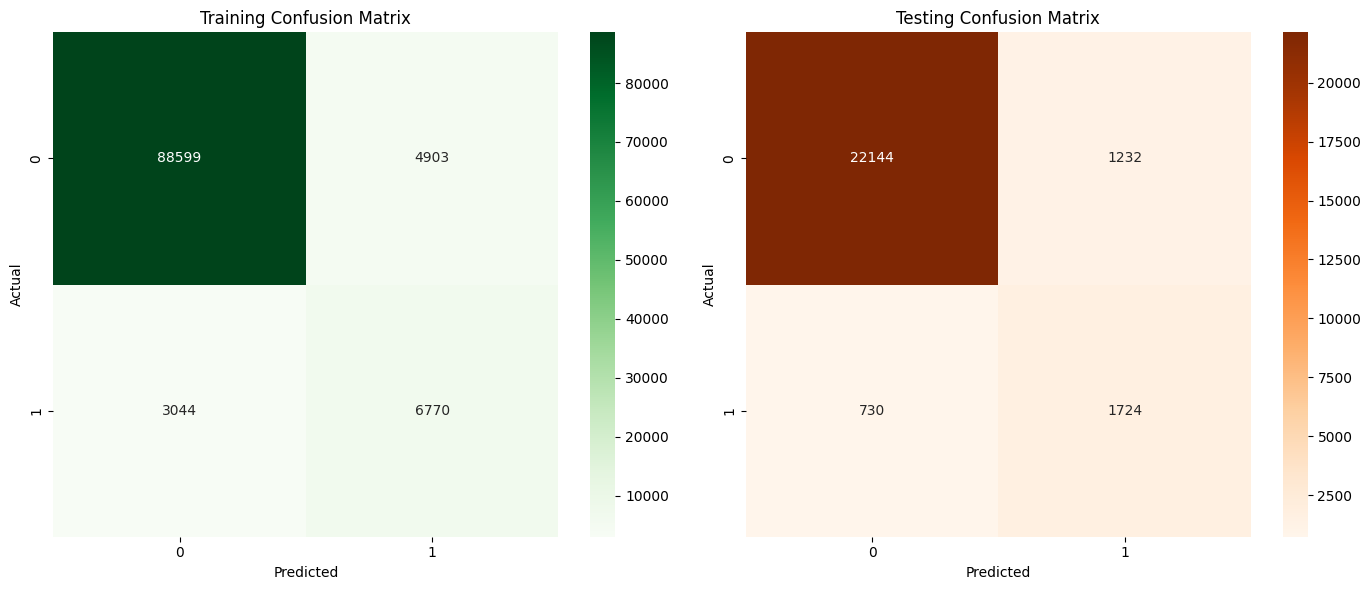

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
    classification_report
)

y_pred_train = best_xgb_model.predict(X_train)
y_pred_test = y_pred 

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.heatmap(confusion_matrix(y_train, y_pred_train), annot=True, fmt='d', cmap='Greens', ax=axes[0])
axes[0].set_title('Training Confusion Matrix')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

sns.heatmap(confusion_matrix(y_test, y_pred_test), annot=True, fmt='d', cmap='Oranges', ax=axes[1])
axes[1].set_title('Testing Confusion Matrix')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

Precision-Recall Curve Plot

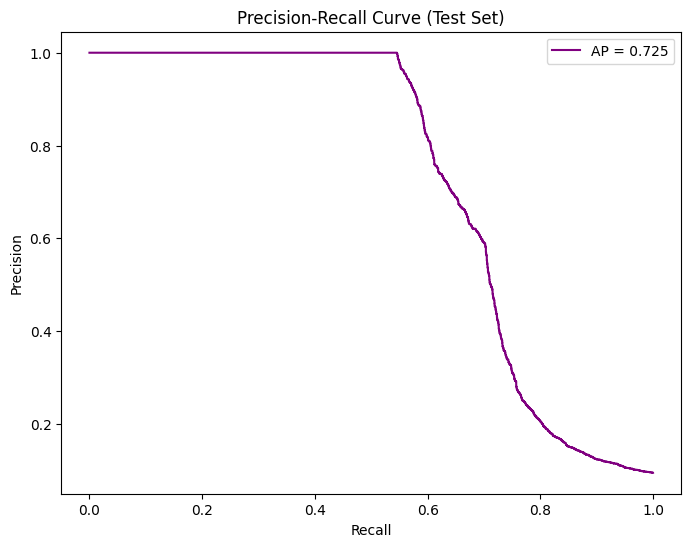

In [50]:
y_prob_train = best_xgb_model.predict_proba(X_train)[:, 1]
y_prob_test  = y_prob 

precision, recall, _ = precision_recall_curve(y_test, y_prob_test)
ap_score = average_precision_score(y_test, y_prob_test)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='purple', label=f'AP = {ap_score:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Test Set)')
plt.legend()
plt.show()

Performance Bar Chart

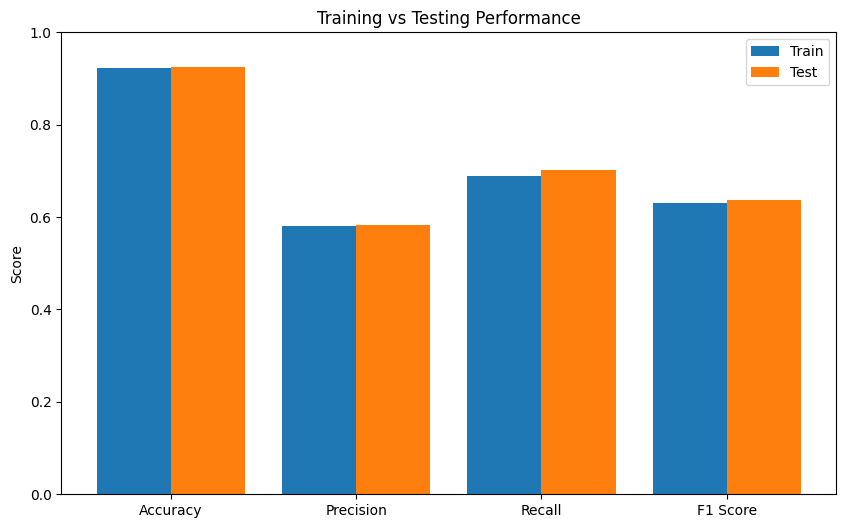

In [51]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
train_scores = [
    accuracy_score(y_train, y_pred_train),
    precision_score(y_train, y_pred_train),
    recall_score(y_train, y_pred_train),
    f1_score(y_train, y_pred_train)
]
test_scores = [
    accuracy_score(y_test, y_pred_test),
    precision_score(y_test, y_pred_test),
    recall_score(y_test, y_pred_test),
    f1_score(y_test, y_pred_test)
]

x = range(len(metrics))
plt.figure(figsize=(10, 6))
plt.bar(x, train_scores, width=0.4, label='Train', align='center')
plt.bar([i + 0.4 for i in x], test_scores, width=0.4, label='Test', align='center')
plt.xticks([i + 0.2 for i in x], metrics)
plt.ylim(0, 1)
plt.ylabel('Score')
plt.title('Training vs Testing Performance')
plt.legend()
plt.show()

Plotting Log Loss (Convergence Check)

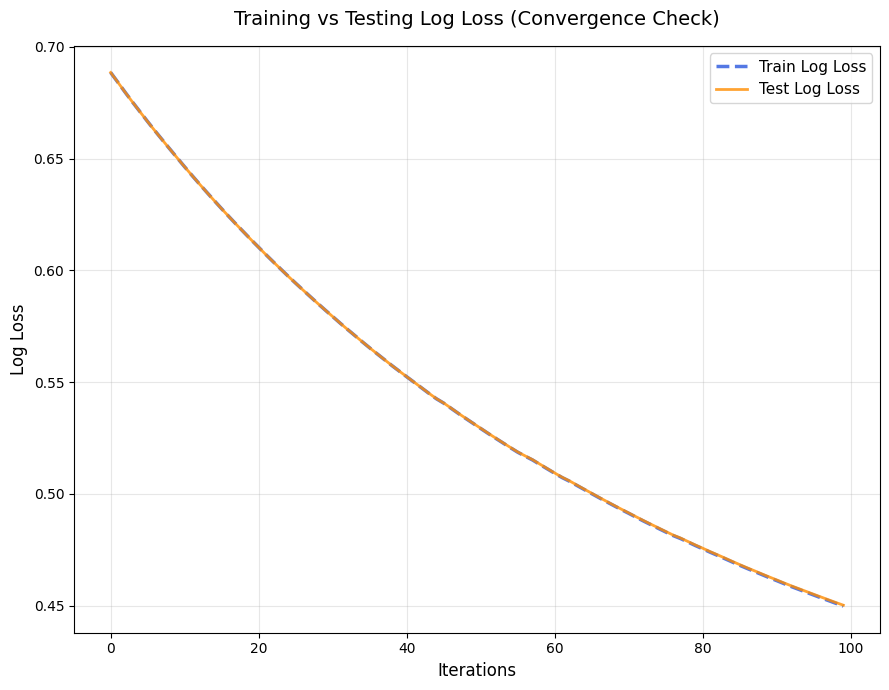

In [52]:
from xgboost import XGBClassifier

eval_set = [(X_train, y_train), (X_test, y_test)]
best_xgb_model.fit(X_train, y_train, eval_set=eval_set, verbose=False)

results = best_xgb_model.evals_result()

epochs = len(results['validation_0']['logloss'])
x_axis = range(0, epochs)

plt.figure(figsize=(9, 7))

plt.plot(
    x_axis,
    results['validation_0']['logloss'],
    label='Train Log Loss',
    color='royalblue',
    linestyle='--',
    linewidth=2.5,
    alpha=0.9
)

plt.plot(
    x_axis,
    results['validation_1']['logloss'],
    label='Test Log Loss',
    color='darkorange',
    linestyle='-',
    linewidth=2,
    alpha=0.8
)

plt.xlabel('Iterations', fontsize=12)
plt.ylabel('Log Loss', fontsize=12)
plt.title('Training vs Testing Log Loss (Convergence Check)', fontsize=14, pad=15)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Threshold Tuning Analysis

In [53]:
import numpy as np
from sklearn.metrics import classification_report

y_probabilities = best_xgb_model.predict_proba(X_test)[:, 1]
thresholds_to_test = [0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.55, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0]

for threshold in thresholds_to_test:
    print(f"Applying threshold: {threshold}")
    print("=" * 30)

    y_pred_new = np.where(y_probabilities >= threshold, 1, 0)

    report = classification_report(y_test, y_pred_new, zero_division=0)
    print(report)
    print("\n" + "-"*50 + "\n")

Applying threshold: 0.1
              precision    recall  f1-score   support

           0       0.00      0.00      0.00     23376
           1       0.10      1.00      0.17      2454

    accuracy                           0.10     25830
   macro avg       0.05      0.50      0.09     25830
weighted avg       0.01      0.10      0.02     25830


--------------------------------------------------

Applying threshold: 0.15
              precision    recall  f1-score   support

           0       0.00      0.00      0.00     23376
           1       0.10      1.00      0.17      2454

    accuracy                           0.10     25830
   macro avg       0.05      0.50      0.09     25830
weighted avg       0.01      0.10      0.02     25830


--------------------------------------------------

Applying threshold: 0.2
              precision    recall  f1-score   support

           0       0.00      0.00      0.00     23376
           1       0.10      1.00      0.17      2454

   